In [ ]:
print("hello")

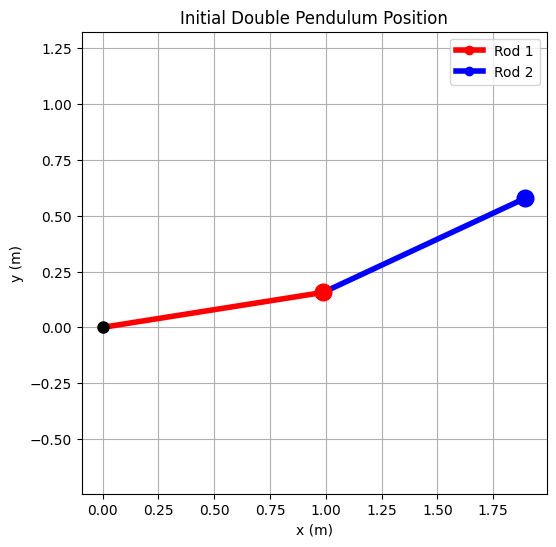

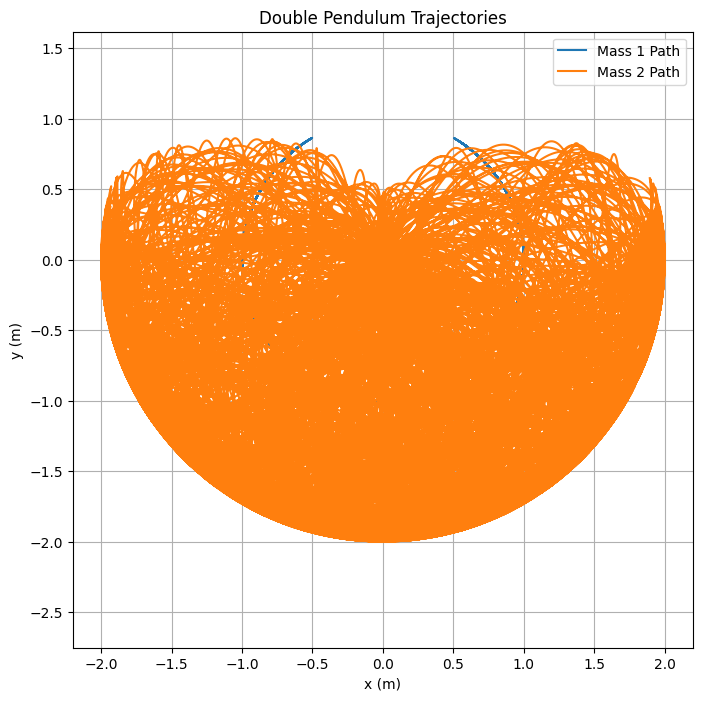

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def double_pendulum_derivs(t, y, m1, m2, L1, L2, g):
    theta1, omega1, theta2, omega2 = y
    
    delta = theta2 - theta1

    denom1 = (m1 + m2)*L1 - m2*L1*np.cos(delta)**2
    denom2 = (L2/L1)*denom1

    domega1 = (m2*L1*omega1**2*np.sin(delta)*np.cos(delta) +
               m2*g*np.sin(theta2)*np.cos(delta) +
               m2*L2*omega2**2*np.sin(delta) -
               (m1 + m2)*g*np.sin(theta1)) / denom1

    domega2 = (-m2*L2*omega2**2*np.sin(delta)*np.cos(delta) +
               (m1 + m2)*g*np.sin(theta1)*np.cos(delta) -
               (m1 + m2)*L1*omega1**2*np.sin(delta) -
               (m1 + m2)*g*np.sin(theta2)) / denom2

    return [omega1, domega1, omega2, domega2]

def simulate_double_pendulum(theta1_deg, theta2_deg, m1=1.0, m2=1.0, L1=1.0, L2=1.0, g=9.81, 
                             t_max=60, dt=0.01):
    # converts degrees to radians
    theta1 = np.radians(theta1_deg)
    theta2 = np.radians(theta2_deg)

    # initial state
    y0 = [theta1, 0.0, theta2, 0.0]

    t_span = (0, t_max)
    t_eval = np.arange(0, t_max, dt)

    sol = solve_ivp(double_pendulum_derivs, t_span, y0, t_eval=t_eval, method='DOP853',
                    args=(m1, m2, L1, L2, g),
                    rtol=1e-9, atol=1e-11)

    return sol

def get_positions(sol, L1, L2):
    theta1 = sol.y[0]
    theta2 = sol.y[2]

    x1 = L1 * np.sin(theta1)
    y1 = -L1 * np.cos(theta1)

    x2 = x1 + L2 * np.sin(theta2)
    y2 = y1 - L2 * np.cos(theta2)

    return x1, y1, x2, y2

def plot_pendulum(x1, y1, x2, y2):
    plt.figure(figsize=(8,8))
    plt.plot(x1, y1, label='Mass 1 Path')
    plt.plot(x2, y2, label='Mass 2 Path')
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.title('Double Pendulum Trajectories')
    plt.legend()
    plt.axis('equal')
    plt.grid()
    plt.show()
    
def plot_initial_position(theta1_deg, theta2_deg, L1=1.0, L2=1.0):
    theta1 = np.radians(theta1_deg)
    theta2 = np.radians(theta2_deg)

    x1 = L1 * np.sin(theta1)
    y1 = -L1 * np.cos(theta1)

    x2 = x1 + L2 * np.sin(theta2)
    y2 = y1 - L2 * np.cos(theta2)

    plt.figure(figsize=(6,6))
    plt.plot([0, x1], [0, y1], 'ro-', lw=4, label='Rod 1')
    plt.plot([x1, x2], [y1, y2], 'bo-', lw=4, label='Rod 2')

    plt.plot(0, 0, 'ko', markersize=8)  # pivot
    plt.plot(x1, y1, 'ro', markersize=12)  # mass 1
    plt.plot(x2, y2, 'bo', markersize=12)  # mass 2

    plt.title('Initial Double Pendulum Position')
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.axis('equal')
    plt.grid()
    plt.legend()
    plt.show()

# set your initial angles here
theta1_deg = float(input("Enter initial angle theta1 (degrees from vertical down): "))
theta2_deg = float(input("Enter initial angle theta2 (degrees from vertical down): "))

plot_initial_position(theta1_deg, theta2_deg)

# Starting Parameters
m1 = 1.0
m2 = 1.0
L1 = 1.0
L2 = 1.0
g = 9.81
t_max = 720
dt = 0.01

sol = simulate_double_pendulum(theta1_deg, theta2_deg, m1, m2, L1, L2, g, t_max, dt)
x1, y1, x2, y2 = get_positions(sol, L1, L2)
plot_pendulum(x1, y1, x2, y2)


In [ ]:
from scipy.io import wavfile
from scipy.signal import square, sawtooth
import numpy as np

def generate_waveform(wave_type, freq, t):
    if wave_type == 'sine':
        return np.sin(2 * np.pi * freq * t)
    elif wave_type == 'square':
        return square(2 * np.pi * freq * t)
    elif wave_type == 'triangle':
        return sawtooth(2 * np.pi * freq * t, width=0.5)
    elif wave_type == 'sawtooth':
        return sawtooth(2 * np.pi * freq * t)
    else:
        raise ValueError(f"Unsupported wave type: {wave_type}")

def apply_echo(signal, fs, delay=0.3, decay=0.5):
    delay_samples = int(delay * fs)
    echoed = np.copy(signal)
    for i in range(delay_samples, len(signal)):
        echoed[i] += decay * signal[i - delay_samples]
    # Normalize to prevent clipping
    max_val = np.max(np.abs(echoed))
    if max_val > 1.0:
        echoed = echoed / max_val
    return echoed

def angles_to_sound(theta1, theta2, fs=44100, base_freq=440,
                    wave_type='sine', echo=False, echo_delay=0.3, echo_decay=0.5,
                    filename="pendulum_sound.wav"):
    """
    Convert theta angles to stereo audio file using amplitude modulation with optional echo.
    """
    duration = len(theta1) / fs
    t = np.linspace(0, duration, len(theta1))

    norm_theta1 = np.clip(theta1 / np.pi, -1, 1)
    norm_theta2 = np.clip(theta2 / np.pi, -1, 1)

    base_wave = generate_waveform(wave_type, base_freq, t)
    print(base_wave)
    
    left = base_wave * norm_theta1
    right = base_wave * norm_theta2

    if echo:
        left = apply_echo(left, fs, delay=echo_delay, decay=echo_decay)
        right = apply_echo(right, fs, delay=echo_delay, decay=echo_decay)

    stereo = np.vstack((left, right)).T
    stereo_int16 = np.int16(stereo * 32767)
    wavfile.write(filename, fs, stereo_int16)
    print(f"Saved: {filename}")


In [ ]:
from scipy.signal import resample

theta1 = sol.y[0]
theta2 = sol.y[2]

# Resample to audio rate
fs = 44100
samples = int(fs * sol.t[-1])
theta1_resampled = resample(theta1, samples)
theta2_resampled = resample(theta2, samples)

# Sonify with triangle wave and echo
angles_to_sound(theta1_resampled, theta2_resampled,
                fs=fs,
                base_freq=220,
                wave_type='triangle',
                echo=False,
                echo_delay=0,
                echo_decay=0,
                filename='pendulum.wav')


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_normalized_amplitudes(theta1, theta2, fs=44100, duration_limit_sec=None, title="Pendulum Amplitude Envelopes"):
    """
    Plot the normalized amplitude (|theta| / max(|theta|)) of theta1 and theta2.
    Optionally limit duration in seconds.
    """
    # Normalize
    norm_theta1 = theta1 / np.max(np.abs(theta1))
    norm_theta2 = theta2 / np.max(np.abs(theta2))

    # Get amplitude envelope (abs value)
    amp1 = np.abs(norm_theta1)
    amp2 = np.abs(norm_theta2)

    # Optional duration limit
    if duration_limit_sec is not None:
        limit_samples = int(fs * duration_limit_sec)
        amp1 = amp1[:limit_samples]
        amp2 = amp2[:limit_samples]
        time = np.linspace(0, duration_limit_sec, limit_samples)
    else:
        time = np.linspace(0, len(theta1) / fs, len(theta1))

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(time, amp1, label='|Theta1|', alpha=0.8)
    plt.plot(time, amp2, label='|Theta2|', alpha=0.8)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Normalized Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
plot_normalized_amplitudes(theta1_resampled, theta2_resampled, fs=44100, duration_limit_sec=50)

NameError: name 'theta1_resampled' is not defined

In [16]:
from scipy.signal import resample

def save_angle_as_raw_pcm(theta, filename, normalize=True, speed_factor=600.0):
    """
    Save pendulum angle array as raw PCM 16-bit signed integer data with optional speed adjustment.

    Parameters:
    - theta: np.array of angles (e.g., radians over time)
    - filename: str, path to save .raw file
    - normalize: bool, whether to normalize to [-1, 1]
    - speed_factor: float, >1 = faster, <1 = slower
    """
    if speed_factor != 1.0:
        new_length = int(len(theta) / speed_factor)
        theta = resample(theta, new_length)

    if normalize:
        max_val = np.max(np.abs(theta))
        if max_val > 0:
            theta_norm = theta / max_val
        else:
            theta_norm = theta
    else:
        theta_norm = theta

    theta_pcm = np.int16(theta_norm * 32767)

    with open(filename, 'wb') as f:
        f.write(theta_pcm.tobytes())

    print(f"Saved raw PCM to: {filename} (speed_factor={speed_factor})")

In [17]:
from scipy.signal import resample

fs = 44100
samples = int(fs * sol.t[-1])

theta1_resampled = resample(sol.y[0], samples)
theta2_resampled = resample(sol.y[2], samples)

save_angle_as_raw_pcm(theta1_resampled, "theta1_left.raw")
save_angle_as_raw_pcm(theta2_resampled, "theta2_right.raw")

Saved raw PCM to: theta1_left.raw (speed_factor=600.0)
Saved raw PCM to: theta2_right.raw (speed_factor=600.0)


In [10]:
import numpy as np
from scipy.io.wavfile import write as wav_write

def combine_raw_pcm_to_wav(left_filename, right_filename, wav_filename, fs=44100):
    """
    Combine two mono raw PCM files into a stereo WAV file.

    Parameters:
    - left_filename: str, path to .raw PCM file for the left channel
    - right_filename: str, path to .raw PCM file for the right channel
    - wav_filename: str, output .wav file path
    - fs: int, sample rate (default 44100)
    """
    # Read raw 16-bit PCM data
    left = np.fromfile(left_filename, dtype=np.int16)
    right = np.fromfile(right_filename, dtype=np.int16)

    # Ensure they are the same length
    min_len = min(len(left), len(right))
    left = left[:min_len]
    right = right[:min_len]

    # Stack into stereo: shape = (samples, 2)
    stereo = np.stack([left, right], axis=-1)

    # Write to WAV
    wav_write(wav_filename, fs, stereo)
    print(f"Stereo WAV written to: {wav_filename}")

In [19]:
combine_raw_pcm_to_wav("theta1_left.raw", "theta2_right.raw", "pendulum.wav")

Stereo WAV written to: pendulum.wav with pans L=-1.0, R=1.0


In [12]:
import numpy as np
from scipy.io.wavfile import write as wav_write

def pan_value_to_gain(pan):
    """
    Convert a pan value in [-1.0, 1.0] to left/right gain using constant power panning.
    """
    pan = np.clip(pan, -1.0, 1.0)
    angle = (pan + 1) * np.pi / 4  # Map [-1, 1] to [0, pi/2]
    left_gain = np.cos(angle)
    right_gain = np.sin(angle)
    return left_gain, right_gain

def combine_raw_pcm_to_wav(left_filename, right_filename, wav_filename, fs=44100, 
                           left_pan=-1.0, right_pan=1.0):
    """
    Combine two mono raw PCM files into a stereo WAV file with optional panning control.

    Parameters:
    - left_filename: str, path to .raw PCM file for the left channel input
    - right_filename: str, path to .raw PCM file for the right channel input
    - wav_filename: str, output .wav file path
    - fs: int, sample rate (default 44100)
    - left_pan: float, pan value for left input in [-1.0, 1.0] (default full left)
    - right_pan: float, pan value for right input in [-1.0, 1.0] (default full right)
    """
    # Load raw 16-bit PCM data
    left_data = np.fromfile(left_filename, dtype=np.int16)
    right_data = np.fromfile(right_filename, dtype=np.int16)

    # Truncate to shortest length
    min_len = min(len(left_data), len(right_data))
    left_data = left_data[:min_len].astype(np.float32)
    right_data = right_data[:min_len].astype(np.float32)

    # Get pan gains
    ll, lr = pan_value_to_gain(left_pan)
    rl, rr = pan_value_to_gain(right_pan)

    # Mix inputs into stereo channels
    left_channel = (left_data * ll) + (right_data * rl)
    right_channel = (left_data * lr) + (right_data * rr)

    # Clip to 16-bit range
    left_channel = np.clip(left_channel, -32768, 32767)
    right_channel = np.clip(right_channel, -32768, 32767)

    # Stack into stereo and convert to int16
    stereo = np.stack([left_channel, right_channel], axis=-1).astype(np.int16)

    # Write WAV file
    wav_write(wav_filename, fs, stereo)
    print(f"Stereo WAV written to: {wav_filename} with pans L={left_pan}, R={right_pan}")


In [20]:
combine_raw_pcm_to_wav("theta1_left.raw", "theta2_right.raw", "pendulum_mono.wav",
                       left_pan=-1.0, right_pan=1.0)

Stereo WAV written to: pendulum_mono.wav with pans L=-1.0, R=1.0
